In [1]:
import pandas as pd

sales = pd.read_csv(r"C:\Users\Bohdan Havryliak\Downloads\archive (2)\amazon_sales_data_uncleaned.csv")

In [46]:
sales.head()

,Title,Rating,Number_of_reviews,price,Listed_price,is_best_seller,is_sponsored,is_couponed,discount_percent
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375,89.68,159.00,False,True,True,43.60
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457,9.99,15.99,False,True,False,37.52
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044,314.00,349.00,False,True,False,10.03
8,Complete Protect: One plan covers all eligible...,4.0,4380,16.99,58.99,False,False,True,71.20
10,Amazon Basics 48-Pack AA Alkaline High-Perform...,4.7,865598,14.99,58.99,True,False,False,74.59


In [3]:
sales = sales.drop(columns='image_url')
sales = sales.drop(columns='product_url')
sales = sales.drop(columns='Price_on_variant')
sales = sales.drop(columns='bought_in_last_month')

In [4]:
sales = sales.drop(columns='buy_box_availability')

In [5]:
sales = sales.drop(columns='sustainability_badges')

In [37]:
sales = sales.drop(columns='collected_at')

In [40]:
sales = sales.drop(columns='delivery_details')

In [41]:
sales.isnull().sum()

Title                0
Rating               0
Number_of_reviews    0
price                0
Listed_price         0
is_best_seller       0
is_sponsored         0
is_couponed          0
discount_percent     0
dtype: int64

In [35]:
(sales.isna().sum() / len(sales) * 100).round(2)

Title                 0.00
Rating                0.00
Number_of_reviews     0.00
price                 0.00
Listed_price          0.00
is_best_seller        0.00
is_sponsored          0.00
is_couponed           0.00
delivery_details     27.46
collected_at          0.00
discount_percent      0.00
dtype: float64

In [8]:
sales = sales.rename(columns={
    "Current/discounted_price": "price"
})

In [36]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 42675 entries, 0 to 42674
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Title              42675 non-null  str    
 1   Rating             42675 non-null  float64
 2   Number_of_reviews  42675 non-null  int64  
 3   price              42675 non-null  float64
 4   Listed_price       42675 non-null  float64
 5   is_best_seller     42675 non-null  bool   
 6   is_sponsored       42675 non-null  bool   
 7   is_couponed        42675 non-null  bool   
 8   delivery_details   30955 non-null  str    
 9   collected_at       42675 non-null  str    
 10  discount_percent   42675 non-null  float64
dtypes: bool(3), float64(4), int64(1), str(3)
memory usage: 2.7 MB


In [30]:
sales.Listed_price = (
    pd.to_numeric(
    sales.Listed_price.replace('$', ""),
    errors='coerce')
    .fillna(sales.Listed_price.median())
)

In [10]:
sales["Number_of_reviews"] = (
    pd.to_numeric(
        sales["Number_of_reviews"].str.replace(",", "", regex=False),
        errors="coerce"
    )
    .fillna(
        pd.to_numeric(
            sales["Number_of_reviews"].str.replace(",", "", regex=False),
            errors="coerce"
        ).median()
    )
    .astype(int)
)


In [11]:
sales.price = (
    sales.price.str.replace(",", '')
    .astype(float)
)
sales["price"] = sales["price"].fillna(sales["price"].median())

In [12]:
sales["Rating"] = sales["Rating"].str.replace(
    " out of 5 stars", "", regex=False
)

sales["Rating"] = pd.to_numeric(
    sales["Rating"],
    errors="coerce"
)

sales["Rating"] = sales["Rating"].fillna(
    sales["Rating"].median()
)


In [13]:
sales.is_best_seller = sales.is_best_seller.map({
    "Best Seller": True,
    'No Badge': False
})
sales.is_best_seller = sales.is_best_seller.astype(bool)

In [14]:
sales.is_sponsored = sales.is_sponsored.map({
    "Sponsored": True,
    'Organic': False
})
sales.is_sponsored = sales.is_sponsored.astype(bool)

In [15]:
sales.is_couponed = sales.is_couponed.map(
    lambda s: False if s == 'No Coupon' else True                                         
)
sales.is_couponed = sales.is_couponed.astype(bool)

In [32]:
sales["discount_percent"] = (
    (sales["Listed_price"] - sales["price"])
    / sales["Listed_price"] * 100
).round(2)

In [45]:
sales.shape

(18283, 9)

In [44]:
sales.drop(
    sales[sales["discount_percent"] < 0].index,
    inplace=True
)


ЗАГАЛЬНИЙ ОГЛЯД

In [75]:
sales.shape

(18283, 9)

In [50]:
sales.Title.value_counts()

Title
Duracell Coppertop 9V Battery, 6 Count (Pack of 1), 9 Volt Battery with Long-lasting Power, All-Purpose Alkaline 9V Battery for Household and Office Devices                                          744
Energizer MAX AA Batteries (16 Pack), Double A Alkaline Batteries                                                                                                                                     566
TRX Training 6 Month On-Demand Membership - Unlimited Access to Expert-Led Workouts, Personalized Programs, Strength, Cardio & Recovery - Train Anytime                                               455
RCA 10.1" WiFi Digital Picture Frame Uhale App Photo Frames Electronic HD IPS Touch Screen Display with 32GB Memory LED Lights, Support USB/SD Card, Slideshow, Instantly Share Photos Videos         371
Lenovo USI Stylus Pen, Chrome OS Support, 4,096 Levels of Pressure Sensitivity, 150 Days Battery Life, AAAA Battery, Works with Chromebook, GX81B10212,Grey                               

In [53]:
sales.agg({
    'Rating': ['mean', 'median'],
    'price': ['mean', 'median']
}
)

,Rating,price
mean,4.474791,73.26101
median,4.500000,29.99000


In [62]:
exp_product = sales.loc[sales.price == sales.price.max(), ['Title']]
min_exp_product = sales.loc[sales.price == sales.price.min(), ['Title']]
print(exp_product, min_exp_product)

                                                  Title
6549  SABRENT 8TB Rocket 4 Plus NVMe 4.0 Gen4 PCIe M...                                                  Title
803  Avery Economy View 3 Ring Binder, 1" Round Rin...


In [67]:
popular_product = sales.loc[sales.Number_of_reviews == sales.Number_of_reviews.max(), ['Title']]
best_product = sales.loc[sales.Rating == sales.Rating.max(), ['Title']]
print(f'popular_product: {popular_product}, \nbest_product: {best_product}')

popular_product:                                                 Title
10  Amazon Basics 48-Pack AA Alkaline High-Perform..., 
best_product:                                                    Title
2029   Dell Pro Thunderbolt 4 Smart Dock SD25TB4 – US...
3112   Monster S220 Bluetooth Soundbar for TV, Blueto...
3823   Casely iPhone 14 Pro Max Case | Fit Check | Gr...
4354   SanDisk 512GB DJ Flash Drive - Up to 1,000 MB/...
4397   CORSAIR Vengeance DDR5 RAM 128GB (2x64GB) 6400...
...                                                  ...
42075  Godox V1 V1Pro S U Flash for Sony Camera TTL S...
42309  Godox V1 V1Pro S U Flash for Sony Camera TTL S...
42438  Godox V1 V1Pro S U Flash for Sony Camera TTL S...
42543  Godox V1 V1Pro S U Flash for Sony Camera TTL S...
42602  Godox V1 V1Pro S U Flash for Sony Camera TTL S...

[133 rows x 1 columns]


In [76]:
count_best_sellers = sales.is_best_seller.sum()
count_sponsored = sales.is_sponsored.sum()
count_couponed = sales.is_couponed.sum()
percent_best_sellers = count_best_sellers / len(sales.is_best_seller) * 100
percent_sponsored = count_sponsored / len(sales.is_sponsored) * 100
percent_couponed = count_couponed / len(sales.is_couponed) * 100
print(f'count_best_sellers: {count_best_sellers}({percent_best_sellers.round(2)}%), count_couponed: {count_couponed}({percent_couponed.round(2)}%), count_sponsored: {count_sponsored}({percent_sponsored.round(2)}%)')

count_best_sellers: 1426(7.8%), count_couponed: 564(3.08%), count_sponsored: 3916(21.42%)


ЧАСТИНА 6

In [81]:
sales.groupby('is_best_seller').agg({
    'price': 'mean',
    'Rating': 'mean',
    'Number_of_reviews': 'mean'
})

,price,Rating,Number_of_reviews
is_best_seller,,,
False,72.686519,4.468808,4003.978229
True,80.052174,4.545512,8994.857644


In [82]:
sales.groupby('is_sponsored').agg({
    'price': 'mean',
    'Rating': 'mean',
    'Number_of_reviews': 'mean'
})

,price,Rating,Number_of_reviews
is_sponsored,,,
False,76.178700,4.456776,4018.442681
True,62.556606,4.540884,5768.325332


In [83]:
sales.groupby('is_couponed').agg({
    'price': 'mean',
    'Rating': 'mean',
    'Number_of_reviews': 'mean'
})

,price,Rating,Number_of_reviews
is_couponed,,,
False,73.320514,4.474293,4449.297759
True,71.391596,4.490426,2632.306738


In [84]:
import matplotlib.pyplot as plt

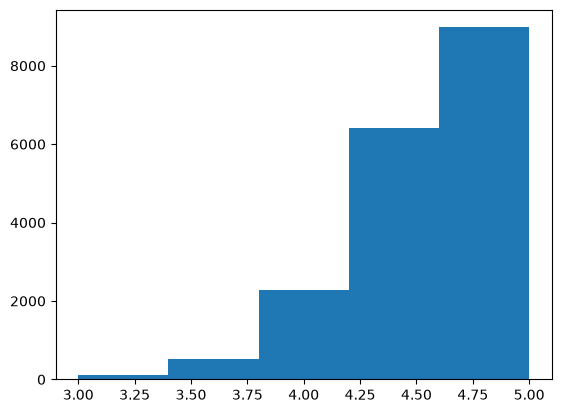

In [93]:
plt.hist(
    sales.Rating,
    bins=5
)

plt.show()

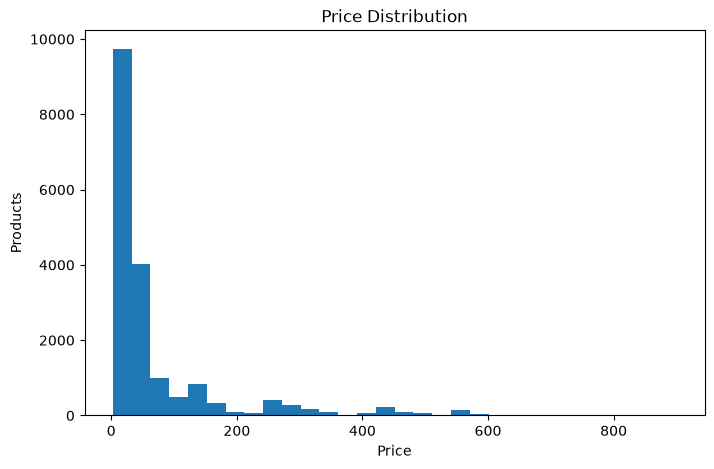

In [87]:
plt.figure(figsize=(8,5))

plt.hist(
    sales["price"],
    bins=30
)

plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Products")

plt.show()

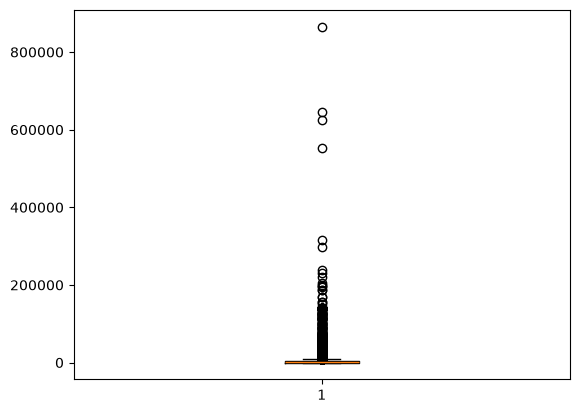

In [94]:
plt.boxplot(sales["Number_of_reviews"])

plt.show()

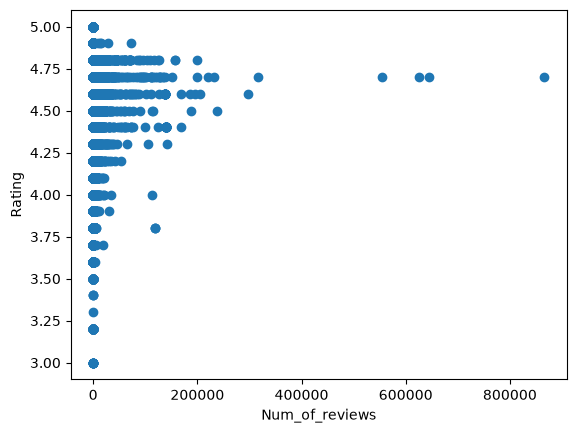

In [96]:
plt.scatter(
    sales.Number_of_reviews,
    sales.Rating
)

plt.ylabel('Rating')
plt.xlabel('Num_of_reviews')

plt.show()

In [98]:
sales.loc[sales.Number_of_reviews.max() == sales.Number_of_reviews, 'Title']

10    Amazon Basics 48-Pack AA Alkaline High-Perform...
Name: Title, dtype: str

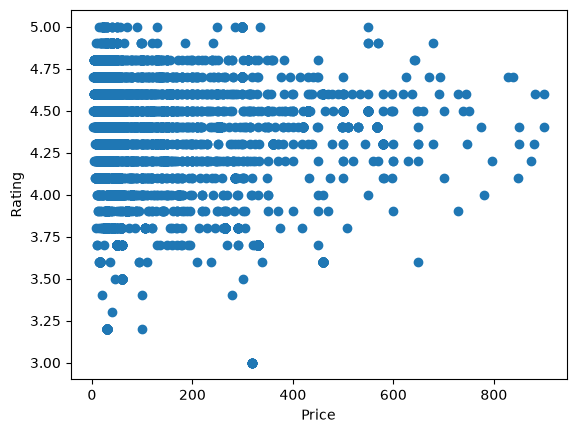

In [89]:
plt.scatter(
    sales["price"],
    sales["Rating"]
)

plt.xlabel("Price")
plt.ylabel("Rating")

plt.show()

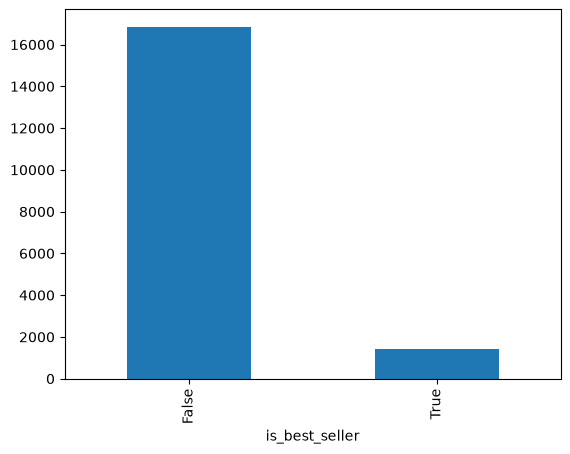

In [90]:
sales["is_best_seller"].value_counts().plot(kind="bar")

plt.show()

<Axes: xlabel='is_couponed'>

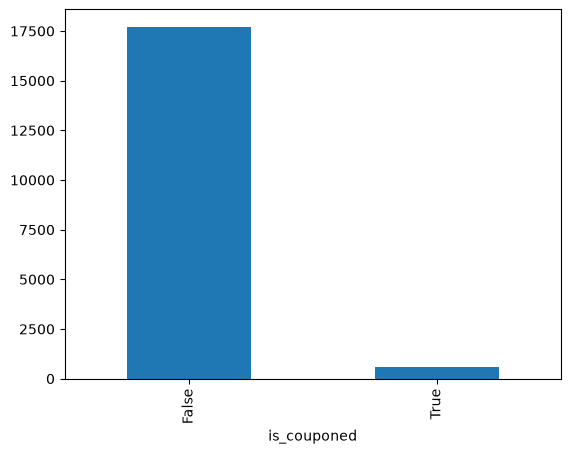

In [100]:
sales.is_couponed.value_counts().plot(kind='bar')

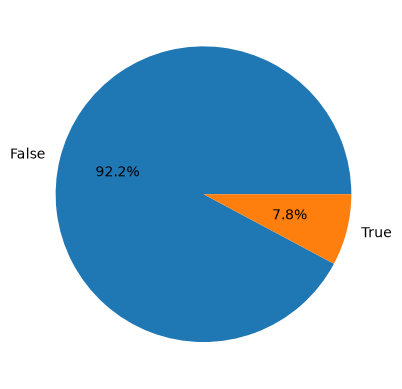

In [91]:
sales["is_best_seller"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.show()

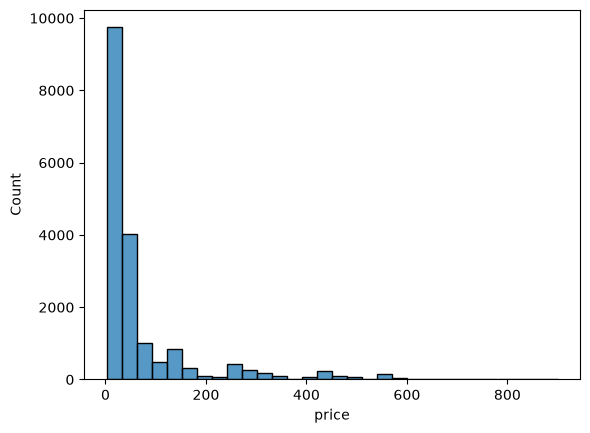

In [101]:
import seaborn as sns

sns.histplot(data=sales, x="price", bins=30)

plt.show()

<Axes: xlabel='price', ylabel='Rating'>

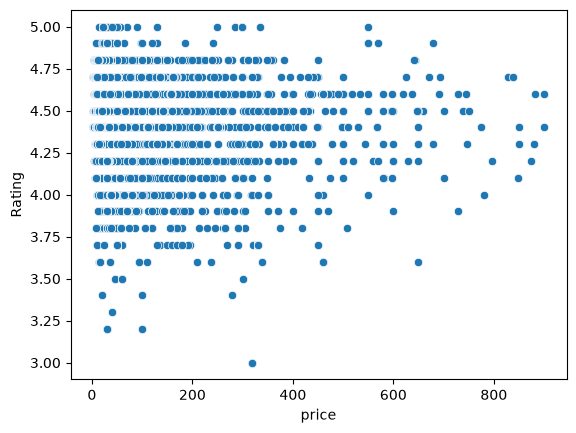

In [102]:
sns.scatterplot(
    data=sales,
    x="price",
    y="Rating"
)

<Axes: >

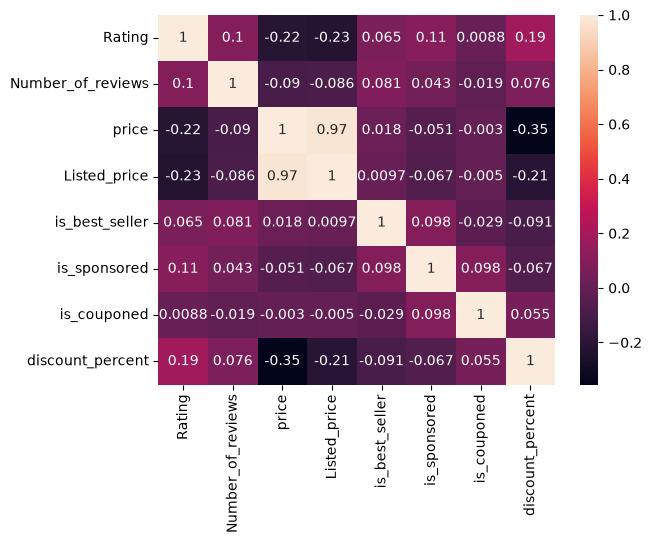

In [ ]:
sns.heatmap(
    sales.corr(numeric_only=True),
    annot=True
)

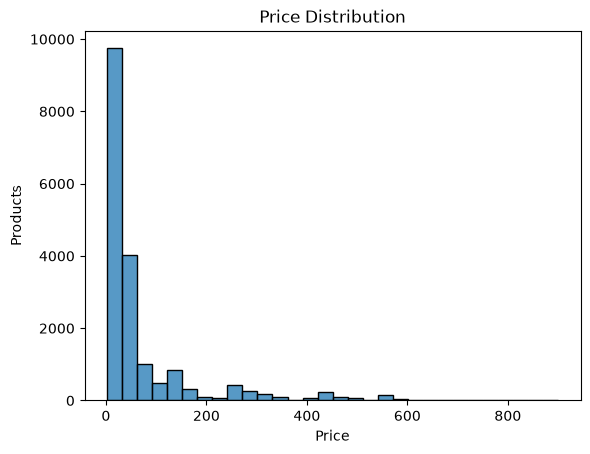

In [104]:
sns.histplot(data=sales, x="price", bins=30)

plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Products")

plt.show()